# Heart Disease Dataset — Modelling

**Objective:** Train and compare four classification models on the preprocessed data.  

| Model | Key Justification |
|---|---|
| Logistic Regression | Strong interpretable baseline for binary classification |
| Random Forest | Handles mixed features well; built-in feature importance |
| XGBoost | High accuracy on tabular data; robust to noise |
| SVM | Effective in small datasets; works well with scaled features |

**Evaluation strategy:** 10-fold cross-validation on training set, then final evaluation on held-out test set.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    RocCurveDisplay, classification_report
)

os.makedirs('../plots', exist_ok=True)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Preprocessed Data

In [2]:
# Load the four splits saved at the end of 2_preprocessing.ipynb
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()  # squeeze converts DataFrame to Series
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test:  {y_test.shape}')

X_train: (240, 17)
X_test:  (60, 17)
y_train: (240,)
y_test:  (60,)


## 3. Define Models

In [3]:
# All models use random_state=42 for reproducibility
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,      # increase iterations to ensure convergence on this dataset
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,   # 100 decision trees in the ensemble
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,  # step size for each boosting round
        eval_metric='logloss',  # suppress warning; logloss is standard for binary classification
        random_state=42
    ),
    'SVM': SVC(
        kernel='rbf',       # radial basis function — good default for non-linear boundaries
        probability=True,   # needed to compute AUC-ROC scores
        random_state=42
    )
}

print('Models defined:')
for name in models:
    print(f'  - {name}')

Models defined:
  - Logistic Regression
  - Random Forest
  - XGBoost
  - SVM


## 4. Cross-Validation

10-fold stratified cross-validation is used instead of a simple train/test split.  
This is especially important here because our dataset is small (≈300 rows) —  
a single split could give misleading results depending on which rows end up in each fold.  
Stratified folds ensure each fold maintains the same class ratio as the full dataset.

In [4]:
# StratifiedKFold preserves the class ratio in each fold
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_results = {}

print('Running 10-fold cross-validation...\n')

for name, model in models.items():
    # Score on multiple metrics across all 10 folds
    acc    = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    recall = cross_val_score(model, X_train, y_train, cv=cv, scoring='recall')
    f1     = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    auc    = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')

    cv_results[name] = {
        'Accuracy':  acc,
        'Recall':    recall,
        'F1':        f1,
        'AUC-ROC':   auc
    }

    print(f'{name}')
    print(f'  Accuracy:  {acc.mean():.3f} ± {acc.std():.3f}')
    print(f'  Recall:    {recall.mean():.3f} ± {recall.std():.3f}')
    print(f'  F1:        {f1.mean():.3f} ± {f1.std():.3f}')
    print(f'  AUC-ROC:   {auc.mean():.3f} ± {auc.std():.3f}')
    print()

Running 10-fold cross-validation...

Logistic Regression
  Accuracy:  0.829 ± 0.076
  Recall:    0.862 ± 0.075
  F1:        0.847 ± 0.065
  AUC-ROC:   0.903 ± 0.062

Random Forest
  Accuracy:  0.800 ± 0.076
  Recall:    0.823 ± 0.069
  F1:        0.817 ± 0.068
  AUC-ROC:   0.893 ± 0.063

XGBoost
  Accuracy:  0.817 ± 0.088
  Recall:    0.838 ± 0.087
  F1:        0.832 ± 0.080
  AUC-ROC:   0.887 ± 0.064

SVM
  Accuracy:  0.812 ± 0.062
  Recall:    0.862 ± 0.090
  F1:        0.832 ± 0.058
  AUC-ROC:   0.892 ± 0.057



In [5]:
# Summarise cross-validation results in a clean table
summary_rows = []
for name, metrics in cv_results.items():
    summary_rows.append({
        'Model':    name,
        'Accuracy': f"{metrics['Accuracy'].mean():.3f} ± {metrics['Accuracy'].std():.3f}",
        'Recall':   f"{metrics['Recall'].mean():.3f} ± {metrics['Recall'].std():.3f}",
        'F1':       f"{metrics['F1'].mean():.3f} ± {metrics['F1'].std():.3f}",
        'AUC-ROC':  f"{metrics['AUC-ROC'].mean():.3f} ± {metrics['AUC-ROC'].std():.3f}",
    })

cv_summary = pd.DataFrame(summary_rows).set_index('Model')
cv_summary

,Accuracy,Recall,F1,AUC-ROC
Model,,,,
Logistic Regression,0.829 ± 0.076,0.862 ± 0.075,0.847 ± 0.065,0.903 ± 0.062
Random Forest,0.800 ± 0.076,0.823 ± 0.069,0.817 ± 0.068,0.893 ± 0.063
XGBoost,0.817 ± 0.088,0.838 ± 0.087,0.832 ± 0.080,0.887 ± 0.064
SVM,0.812 ± 0.062,0.862 ± 0.090,0.832 ± 0.058,0.892 ± 0.057


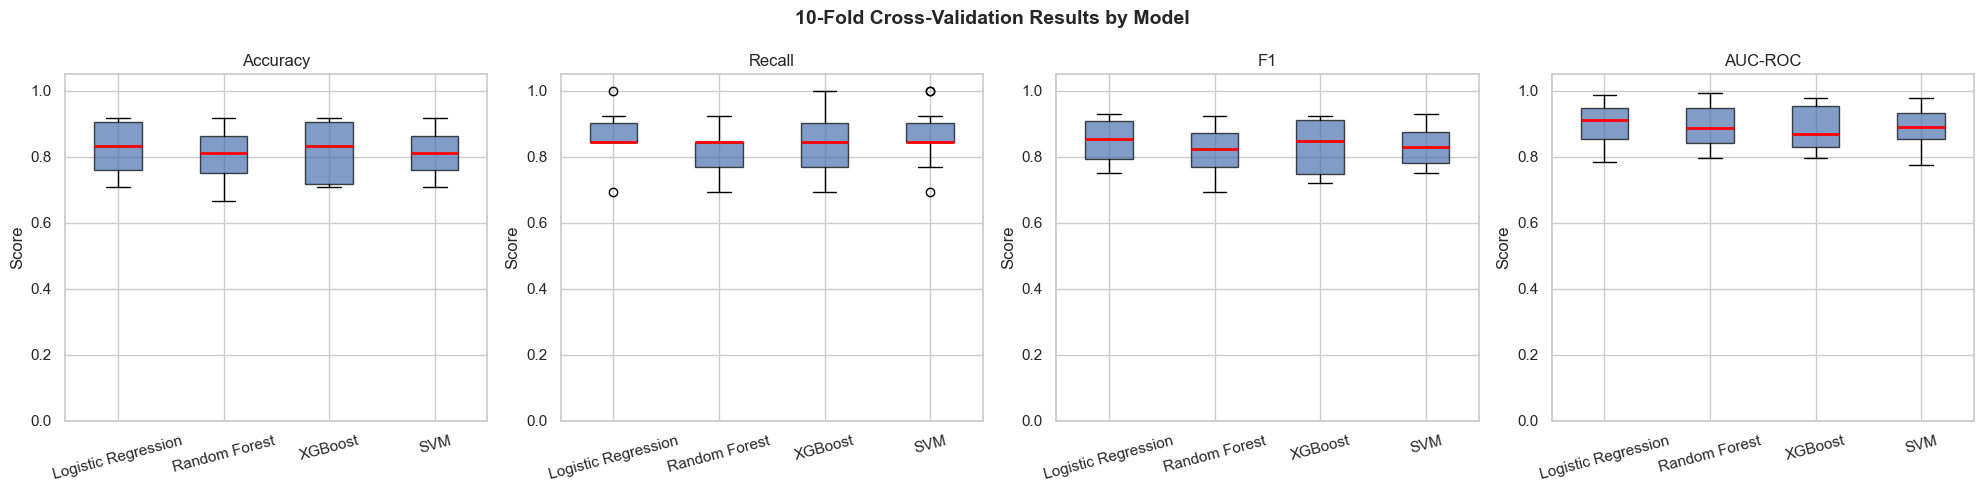

In [6]:
# Visualise cross-validation scores as boxplots across all 10 folds
# Boxplots show variance across folds — a wide box means unstable performance
metrics_to_plot = ['Accuracy', 'Recall', 'F1', 'AUC-ROC']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, metric in enumerate(metrics_to_plot):
    data = [cv_results[name][metric] for name in models]
    axes[i].boxplot(data, tick_labels=list(models.keys()), patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(metric)
    axes[i].set_ylabel('Score')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].set_ylim(0, 1.05)

plt.suptitle('10-Fold Cross-Validation Results by Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/cv_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Train Final Models on Full Training Set

Cross-validation was used to compare models.  
Now we train each model on the full training set before evaluating on the held-out test set.

In [7]:
# Train all models on the complete training set
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f'{name} — trained.')

Logistic Regression — trained.
Random Forest — trained.
XGBoost — trained.
SVM — trained.


## 6. Evaluate on Test Set

In [8]:
# Evaluate each trained model on the held-out test set
test_results = []

for name, model in trained_models.items():
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]  # probability of class 1 (disease)

    test_results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'AUC-ROC':   roc_auc_score(y_test, y_pred_prob)
    })

test_df = pd.DataFrame(test_results).set_index('Model').round(3)

# Highlight the best value in each column
test_df.style.highlight_max(axis=0, color='#d4edda')

,Accuracy,Precision,Recall,F1,AUC-ROC
Model,,,,,
Logistic Regression,0.817000,0.824000,0.848000,0.836000,0.866000
Random Forest,0.767000,0.788000,0.788000,0.788000,0.864000
XGBoost,0.750000,0.781000,0.758000,0.769000,0.853000
SVM,0.783000,0.794000,0.818000,0.806000,0.857000


## 7. Confusion Matrices

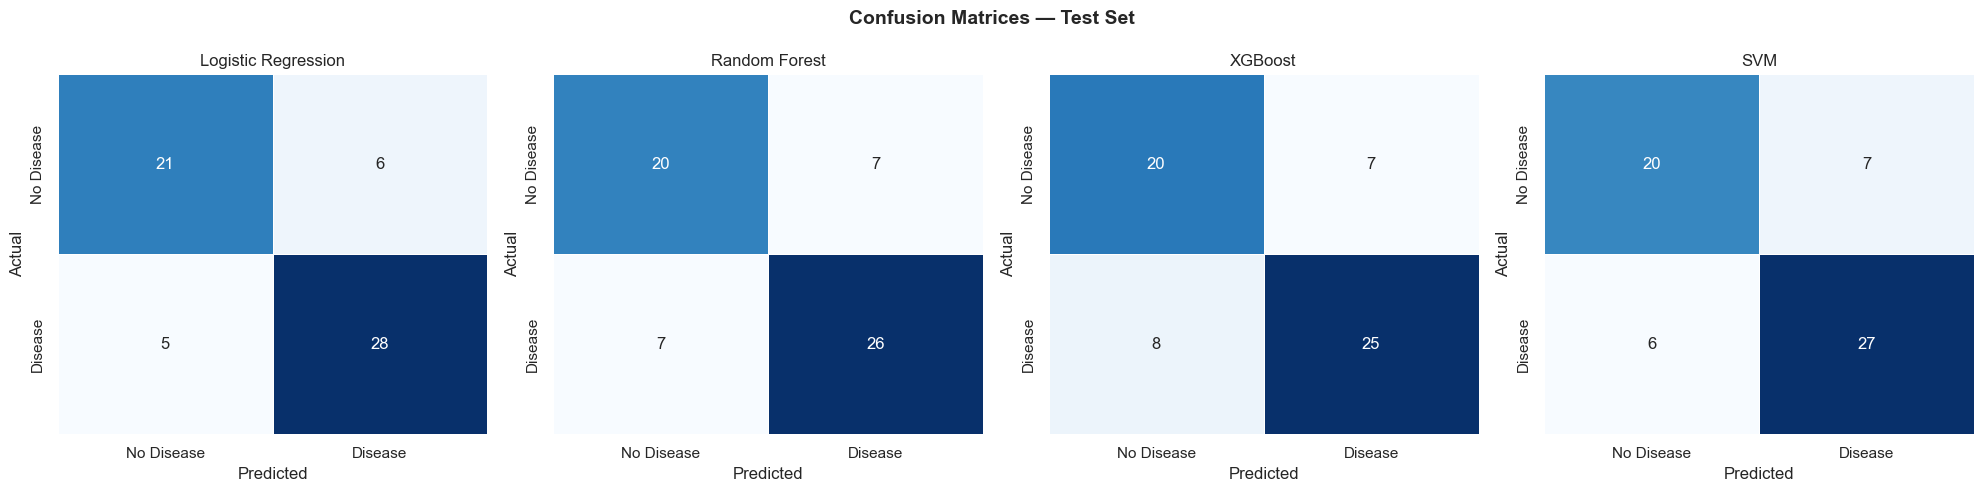

In [9]:
# Confusion matrix shows the breakdown of correct and incorrect predictions
# TP = correctly predicted disease, TN = correctly predicted no disease
# FP = false alarm, FN = missed disease case (most dangerous error in medical context)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                linewidths=0.5, cbar=False)
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. ROC Curves

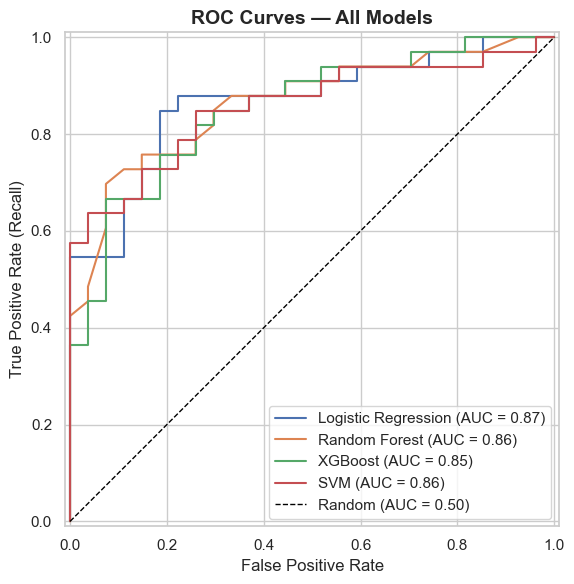

In [10]:
# ROC curve plots True Positive Rate vs False Positive Rate at different thresholds
# A model with AUC = 1.0 is perfect; AUC = 0.5 is no better than random guessing
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for (name, model), color in zip(trained_models.items(), colors):
    RocCurveDisplay.from_estimator(
        model, X_test, y_test,
        name=name, ax=ax,
        curve_kwargs={'color': color}
    )
# Diagonal dashed line represents a random classifier (AUC = 0.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.50)')
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../plots/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Feature Importance (Random Forest & XGBoost)

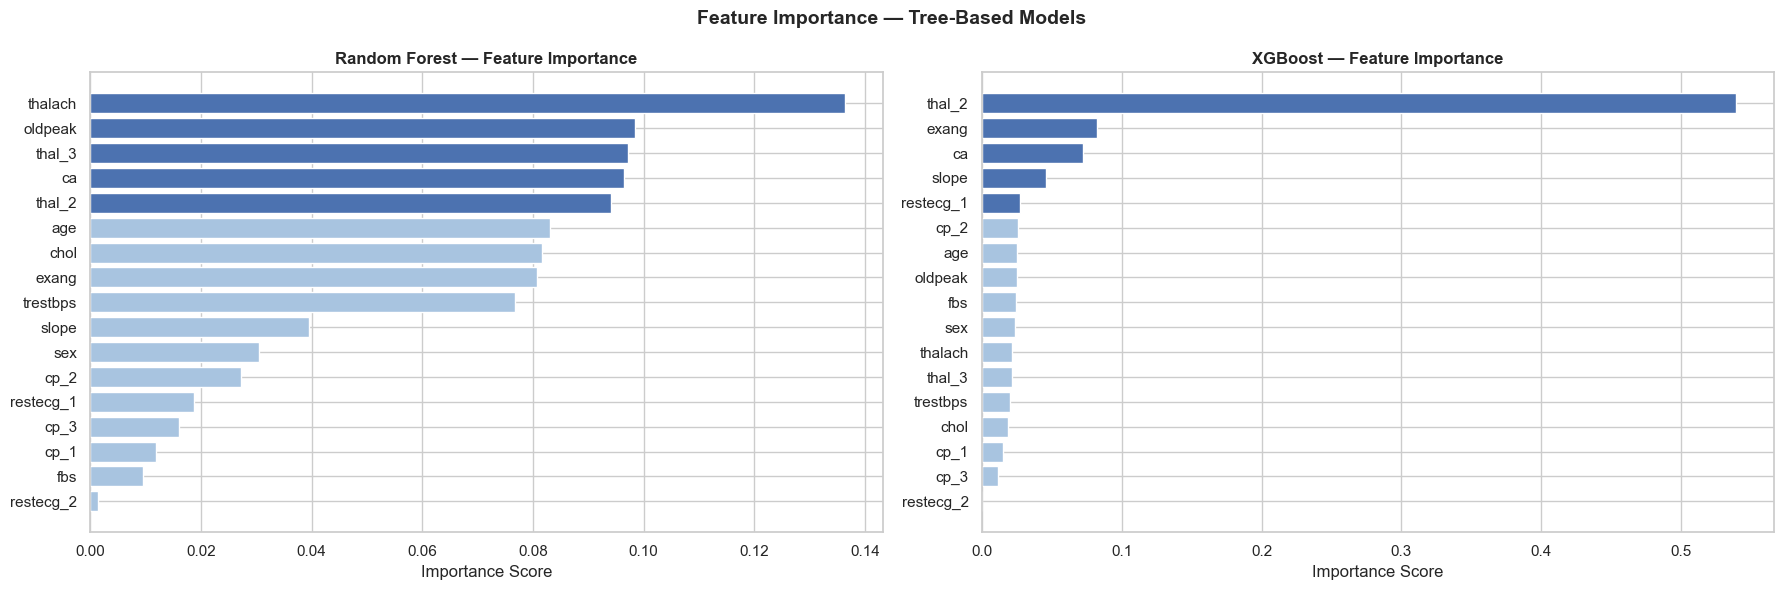

In [11]:
# Tree-based models provide built-in feature importance scores
# Higher score = feature contributed more to reducing impurity across all trees
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, name in zip(axes, ['Random Forest', 'XGBoost']):
    model = trained_models[name]
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    importances = importances.sort_values(ascending=True)

    # Highlight top 5 features in a darker colour
    colors = ['#4C72B0' if i >= len(importances) - 5 else '#a8c4e0'
              for i in range(len(importances))]

    ax.barh(importances.index, importances.values, color=colors, edgecolor='white')
    ax.set_title(f'{name} — Feature Importance', fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.suptitle('Feature Importance — Tree-Based Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Model Comparison — Bar Chart

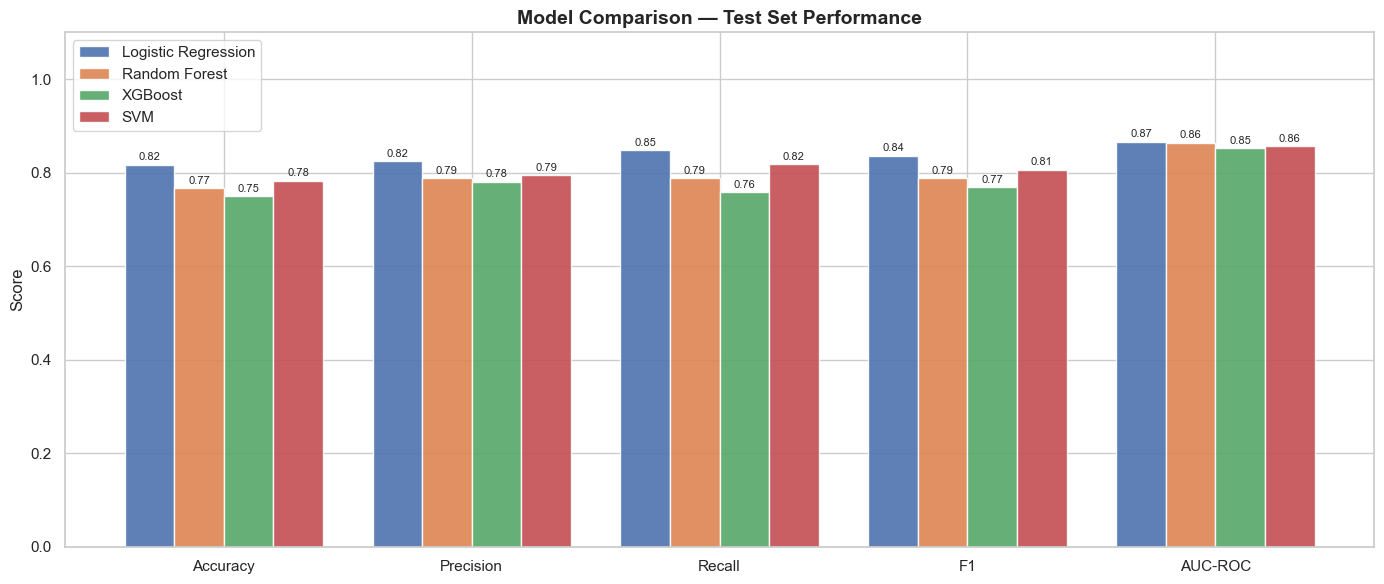

In [12]:
# Side-by-side bar chart comparing all models across all metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
x = np.arange(len(metrics))
width = 0.2
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (name, color) in enumerate(zip(test_df.index, colors)):
    values = test_df.loc[name, metrics].values
    bars = ax.bar(x + i * width, values, width, label=name,
                  color=color, edgecolor='white', alpha=0.9)

    # Annotate each bar with its value
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Test Set Performance', fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('../plots/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Classification Reports

In [13]:
# Full classification report for each model
# Shows per-class precision, recall, and F1 — useful for spotting class-specific weaknesses
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    print(f'=== {name} ===')
    print(classification_report(y_test, y_pred,
                                 target_names=['No Disease', 'Heart Disease']))
    print()

=== Logistic Regression ===
               precision    recall  f1-score   support

   No Disease       0.81      0.78      0.79        27
Heart Disease       0.82      0.85      0.84        33

     accuracy                           0.82        60
    macro avg       0.82      0.81      0.81        60
 weighted avg       0.82      0.82      0.82        60


=== Random Forest ===
               precision    recall  f1-score   support

   No Disease       0.74      0.74      0.74        27
Heart Disease       0.79      0.79      0.79        33

     accuracy                           0.77        60
    macro avg       0.76      0.76      0.76        60
 weighted avg       0.77      0.77      0.77        60


=== XGBoost ===
               precision    recall  f1-score   support

   No Disease       0.71      0.74      0.73        27
Heart Disease       0.78      0.76      0.77        33

     accuracy                           0.75        60
    macro avg       0.75      0.75      0.75

## 12. Best Model Selection

In a medical classification task, **Recall** is the most critical metric —  
a missed heart disease case (False Negative) is more dangerous than a false alarm (False Positive).  
We therefore prioritise the model with the highest Recall, using AUC-ROC as a tiebreaker.

In [14]:
# Automatically identify the best model by Recall, then AUC-ROC as tiebreaker
best_model_name = test_df.sort_values(
    by=['Recall', 'AUC-ROC'], ascending=False
).index[0]

best_model = trained_models[best_model_name]

print(f'Best model: {best_model_name}')
print(f'\nTest set performance:')
print(test_df.loc[best_model_name])

Best model: Logistic Regression

Test set performance:
Accuracy     0.817
Precision    0.824
Recall       0.848
F1           0.836
AUC-ROC      0.866
Name: Logistic Regression, dtype: float64


## 13. Modelling Summary

---

**Cross-Validation (10-fold):**

| Model | Accuracy | Recall | F1 | AUC-ROC |
|---|---|---|---|---|
| Logistic Regression | 0.829 ± 0.076 | 0.862 ± 0.075 | 0.847 ± 0.065 | 0.903 ± 0.062 |
| Random Forest       | 0.800 ± 0.076 | 0.823 ± 0.069 | 0.817 ± 0.068 | 0.893 ± 0.063 |
| XGBoost             | 0.817 ± 0.088 | 0.838 ± 0.087 | 0.832 ± 0.080 | 0.887 ± 0.064 |
| SVM                 | 0.812 ± 0.062 | 0.862 ± 0.090 | 0.832 ± 0.058 | 0.892 ± 0.057 |

**Test Set Results:**

| Model | Accuracy | Precision | Recall | F1 | AUC-ROC |
|---|---|---|---|---|---|
| Logistic Regression | 0.82 | 0.82 | 0.85 | 0.84 | 0.87 |
| Random Forest       | 0.77 | 0.79 | 0.79 | 0.79 | 0.86 |
| XGBoost             | 0.75 | 0.78 | 0.76 | 0.77 | 0.85 |
| SVM                 | 0.78 | 0.79 | 0.82 | 0.81 | 0.86 |

**Best Model: Logistic Regression**
Logistic Regression was selected as the best model based on its consistent
superiority across both cross-validation and test set evaluation. In a medical
context, Recall is the primary metric since a missed heart disease case (False
Negative) carries far greater risk than a false alarm (False Positive).
Logistic Regression achieved the highest Recall on both CV (0.862) and test set
(0.85), the highest AUC-ROC (0.87 on test, 0.903 on CV), and the highest overall
Accuracy (0.82). Additionally, its confusion matrix showed the fewest missed
disease cases — only 5 False Negatives compared to 7 for Random Forest, 8 for
XGBoost, and 6 for SVM.

**Stability (CV boxplots):**
- SVM was the most consistent model — narrowest interquartile range across
  Accuracy, F1 and AUC-ROC, with only 2 outlier folds on Recall
- XGBoost was the least stable — widest boxes on Accuracy and Recall, with
  1 outlier fold near 0.70 on Recall — likely due to sensitivity to small
  dataset size
- Logistic Regression and Random Forest showed similar variance levels, though
  Logistic Regression maintained a higher median across all metrics

**ROC Curves:**
- All four models significantly outperform random guessing (AUC = 0.50)
- Logistic Regression (AUC = 0.87) achieves the best trade-off between True
  Positive Rate and False Positive Rate across all thresholds
- Random Forest and SVM are close behind (both AUC = 0.86), with XGBoost
  slightly lower (AUC = 0.85)
- All curves rise steeply in the top-left region, indicating strong performance
  at low false positive rates

**Feature Importances (Random Forest vs XGBoost):**
- Random Forest top features: `thalach` (0.13), `oldpeak` (0.10), `thal_3`
  (0.09), `ca` (0.09), `thal_2` (0.09) — importance is spread relatively
  evenly across many features
- XGBoost top features: `thal_2` dominates heavily (0.53), followed by `exang`
  (0.09), `ca` (0.07), `slope` (0.05) — XGBoost relies far more heavily on a
  single feature
- Both models agree that `thal`, `ca`, and `exang` are strong predictors,
  which is consistent with the EDA findings (correlations of −0.34, −0.41,
  and −0.44 with target respectively)
- Notably, `chol` and `fbs` ranked near the bottom in both models, confirming
  the EDA observation that they have negligible predictive value

**Next Step:** Move to `4_evaluation.ipynb` for deeper analysis of the
best model (Logistic Regression).